In [1]:
import os
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyvis.network import Network

os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis")

print("Working directory:", os.getcwd())

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis


In [2]:
ged = pd.read_csv("data/GEDEvent_v25_1.csv")

ged['date_start'] = pd.to_datetime(ged['date_start'])

ethiopia = ged[
    (ged['country'] == 'Ethiopia') &
    (ged['date_start'] >= '2020-11-01') &
    (ged['date_start'] <= '2022-11-30')
].copy()

print(f"Total events: {len(ethiopia)}")
print(f"\nViolence types:")
print(ethiopia['type_of_violence'].value_counts())
print(f"\nSample of side_a values:")
print(ethiopia['side_a'].value_counts().head(10))
print(f"\nSample of side_b values:")
print(ethiopia['side_b'].value_counts().head(10))

Total events: 1764

Violence types:
type_of_violence
1    1203
3     554
2       7
Name: count, dtype: int64

Sample of side_a values:
side_a
Government of Ethiopia                           1405
Government of Eritrea                             158
Government of Eritrea, Government of Ethiopia      62
TPLF                                               54
OLA                                                45
Fano                                               25
Government of Somalia                               6
Amhara                                              3
OLA - Fekade Abdisa faction                         2
Burji                                               1
Name: count, dtype: int64

Sample of side_b values:
side_b
TPLF          699
Civilians     554
OLA           495
Al-Shabaab      6
Gumuz           3
GLF             3
Oromo           2
Guji            1
Nuer            1
Name: count, dtype: int64


/var/folders/ls/jfgzf4j13hx__mtdgv2_0xbw0000gn/T/ipykernel_7429/1508399459.py:1: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  ged = pd.read_csv("data/GEDEvent_v25_1.csv")


In [3]:
print("side_b values:")
print(ethiopia['side_b'].value_counts())

side_b values:
side_b
TPLF          699
Civilians     554
OLA           495
Al-Shabaab      6
Gumuz           3
GLF             3
Oromo           2
Guji            1
Nuer            1
Name: count, dtype: int64


In [4]:
# Step 1: Remove one-sided violence against civilians
battle_events = ethiopia[ethiopia['side_b'] != 'Civilians'].copy()
print(f"Events after removing civilian targeting: {len(battle_events)}")

# Step 2: Split coalition entries into individual actors
# "Government of Eritrea, Government of Ethiopia" becomes two separate actors
def split_actors(actor_string):
    """Split comma-separated actor names into a list."""
    if pd.isna(actor_string):
        return []
    parts = [a.strip() for a in actor_string.split(',')]
    # Rejoin parts that belong to one actor name
    # UCDP uses format like "Government of Ethiopia" so we check for known patterns
    merged = []
    i = 0
    while i < len(parts):
        # Check if this part starts with "Government of" - it is a complete actor
        if parts[i].startswith('Government of'):
            merged.append(parts[i])
            i += 1
        # Check if next part starts with "Government of" - current part is complete
        elif i + 1 < len(parts) and parts[i + 1].startswith('Government of'):
            merged.append(parts[i])
            i += 1
        # Check if this is the last part - it is complete
        elif i == len(parts) - 1:
            merged.append(parts[i])
            i += 1
        # Otherwise, this part and next might be one actor name
        # But in UCDP, commas separate distinct actors, so treat as separate
        else:
            merged.append(parts[i])
            i += 1
    return merged

# Test the split function
test_cases = [
    "Government of Eritrea, Government of Ethiopia",
    "TPLF",
    "OLA",
    "Government of Ethiopia"
]
for t in test_cases:
    print(f"  '{t}' -> {split_actors(t)}")

Events after removing civilian targeting: 1210
  'Government of Eritrea, Government of Ethiopia' -> ['Government of Eritrea', 'Government of Ethiopia']
  'TPLF' -> ['TPLF']
  'OLA' -> ['OLA']
  'Government of Ethiopia' -> ['Government of Ethiopia']


In [5]:
from itertools import product

edges = []

for _, row in battle_events.iterrows():
    actors_a = split_actors(row['side_a'])
    actors_b = split_actors(row['side_b'])
    date = row['date_start']
    fatalities = row['best']
    violence_type = row['type_of_violence']
    
    # Create an edge for every combination of side_a and side_b actors
    for a, b in product(actors_a, actors_b):
        # Alphabetical ordering so (A,B) and (B,A) count as the same edge
        actor_pair = tuple(sorted([a, b]))
        edges.append({
            'actor_1': actor_pair[0],
            'actor_2': actor_pair[1],
            'date': date,
            'fatalities': fatalities,
            'violence_type': violence_type
        })

edge_df = pd.DataFrame(edges)
print(f"Total pairwise interactions: {len(edge_df)}")
print(f"\nUnique actor pairs (edges):")
print(edge_df.groupby(['actor_1', 'actor_2']).size().sort_values(ascending=False))

Total pairwise interactions: 1214

Unique actor pairs (edges):
actor_1                 actor_2               
Government of Ethiopia  TPLF                      699
                        OLA                       495
Al-Shabaab              Government of Somalia       6
Amhara                  Gumuz                       3
GLF                     Government of Ethiopia      3
Amhara                  Oromo                       2
Gumuz                   Shinasha                    2
Agaw                    Gumuz                       1
Burji                   Guji                        1
Gumuz                   Oromo                       1
Murle                   Nuer                        1
dtype: int64


In [6]:
# Aggregate edges: count interactions and sum fatalities per actor pair
edge_weights = edge_df.groupby(['actor_1', 'actor_2']).agg(
    weight=('date', 'size'),
    total_fatalities=('fatalities', 'sum')
).reset_index()

print("Edge list with weights:")
print(edge_weights.sort_values('weight', ascending=False).to_string(index=False))

# Build the network
G = nx.Graph()

for _, row in edge_weights.iterrows():
    G.add_edge(
        row['actor_1'],
        row['actor_2'],
        weight=row['weight'],
        fatalities=row['total_fatalities']
    )

print(f"\nNetwork summary:")
print(f"  Nodes (actors): {G.number_of_nodes()}")
print(f"  Edges (rivalries): {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.3f}")
print(f"\nAll actors in the network:")
for node in sorted(G.nodes()):
    print(f"  {node}")

Edge list with weights:
               actor_1                actor_2  weight  total_fatalities
Government of Ethiopia                   TPLF     699            307557
Government of Ethiopia                    OLA     495              1045
            Al-Shabaab  Government of Somalia       6                 3
                Amhara                  Gumuz       3               353
                   GLF Government of Ethiopia       3                42
                Amhara                  Oromo       2                26
                 Gumuz               Shinasha       2               352
                  Agaw                  Gumuz       1               130
                 Burji                   Guji       1                 8
                 Gumuz                  Oromo       1               222
                 Murle                   Nuer       1                 8

Network summary:
  Nodes (actors): 15
  Edges (rivalries): 11
  Density: 0.105

All actors in the network:
  Ag

In [7]:
# Compute centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)
closeness_cent = nx.closeness_centrality(G)

# Also compute weighted degree (strength = total interactions)
strength = dict(G.degree(weight='weight'))

# Combine into a DataFrame
centrality_df = pd.DataFrame({
    'actor': list(G.nodes()),
    'degree': [G.degree(n) for n in G.nodes()],
    'strength': [strength[n] for n in G.nodes()],
    'degree_centrality': [degree_cent[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G.nodes()],
    'eigenvector_centrality': [eigenvector_cent[n] for n in G.nodes()],
    'closeness_centrality': [closeness_cent[n] for n in G.nodes()]
})

centrality_df = centrality_df.sort_values('strength', ascending=False)

print("Actor centrality measures (sorted by interaction volume):\n")
print(centrality_df.to_string(index=False))

Actor centrality measures (sorted by interaction volume):

                 actor  degree  strength  degree_centrality  betweenness_centrality  eigenvector_centrality  closeness_centrality
Government of Ethiopia       3      1197           0.214286                0.032967            2.179996e-05              0.214286
                  TPLF       1       699           0.071429                0.000000            1.258621e-05              0.128571
                   OLA       1       495           0.071429                0.000000            1.258621e-05              0.128571
                 Gumuz       4         7           0.285714                0.054945            6.358555e-01              0.285714
            Al-Shabaab       1         6           0.071429                0.000000            1.970604e-12              0.071429
 Government of Somalia       1         6           0.071429                0.000000            1.970604e-12              0.071429
                Amhara       2 

In [8]:
# Community detection using Louvain algorithm
partition = community_louvain.best_partition(G)

# Add community labels to centrality dataframe
centrality_df['community'] = centrality_df['actor'].map(partition)

print("Community assignments:\n")
for comm_id in sorted(set(partition.values())):
    members = [actor for actor, comm in partition.items() if comm == comm_id]
    print(f"  Community {comm_id}: {', '.join(members)}")

print(f"\nModularity: {community_louvain.modularity(partition, G):.3f}")

Community assignments:

  Community 0: GLF, Government of Ethiopia, OLA, TPLF
  Community 1: Agaw, Gumuz, Amhara, Oromo, Shinasha
  Community 2: Al-Shabaab, Government of Somalia
  Community 3: Murle, Nuer
  Community 4: Burji, Guji

Modularity: 0.028


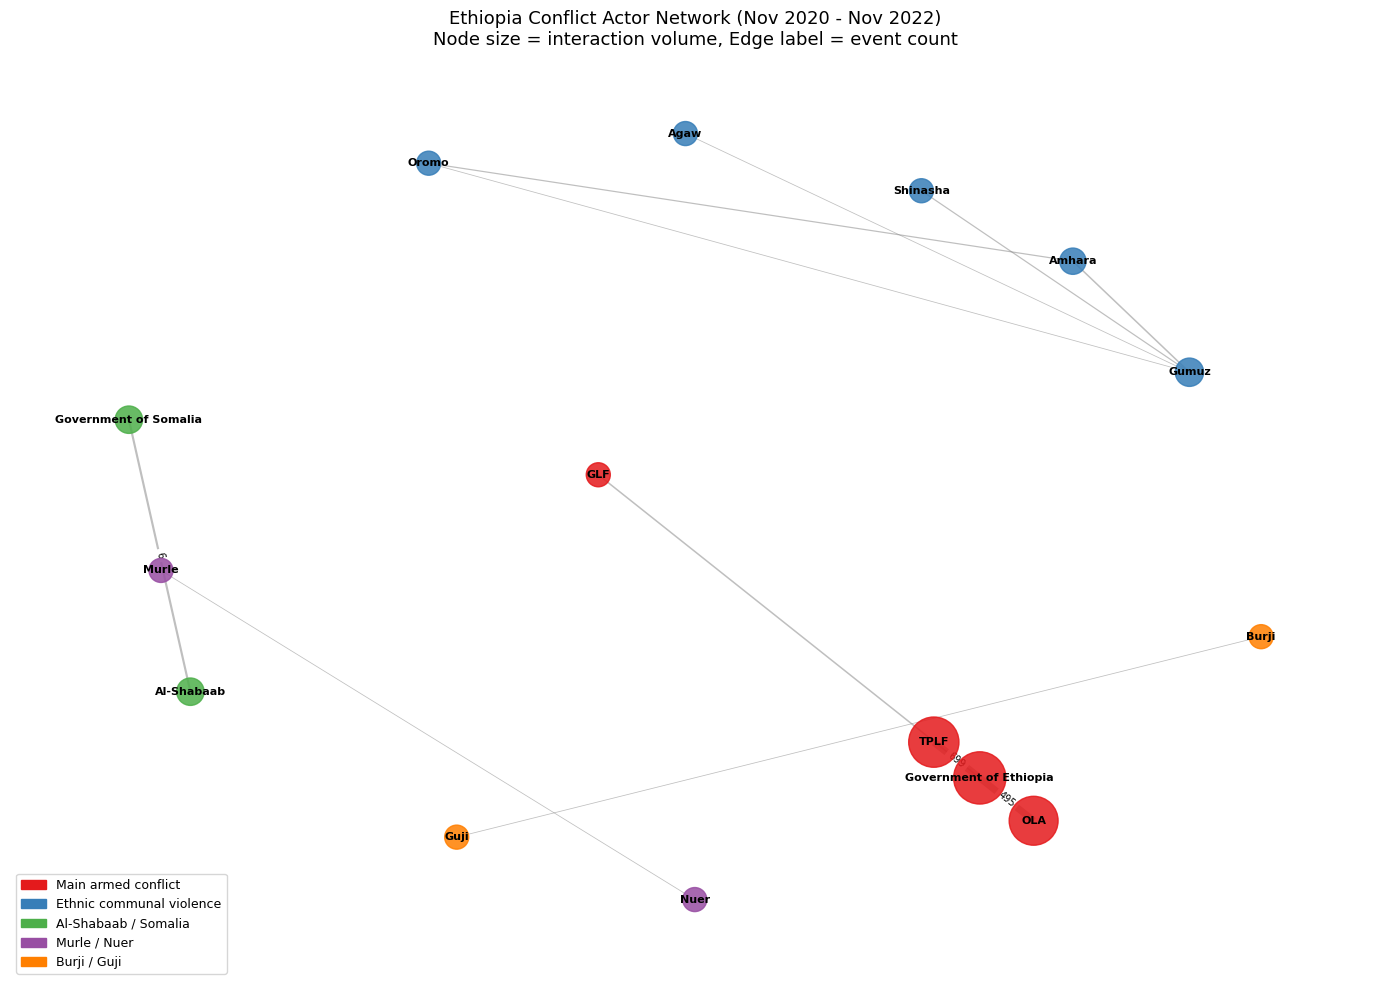

Saved to outputs/01_static_network.png


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color map for communities
community_colors = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3', 4: '#ff7f00'}
node_colors = [community_colors[partition[node]] for node in G.nodes()]

# Node size proportional to strength (log scale for readability)
import numpy as np
strengths = [strength[node] for node in G.nodes()]
# Use log scale so huge nodes don't crush small ones
node_sizes = [max(300, np.log1p(s) * 200) for s in strengths]

# Edge width proportional to weight (log scale)
edge_weights_list = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths = [max(0.5, np.log1p(w) * 0.8) for w in edge_weights_list]

# Layout
pos = nx.spring_layout(G, k=2.5, seed=42)

# Draw edges
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.5, edge_color='gray')

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors, alpha=0.85)

# Draw labels
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

# Add edge weight labels for major edges
major_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 5]
edge_labels = {(u, v): G[u][v]['weight'] for u, v in major_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7)

# Legend
legend_patches = [
    mpatches.Patch(color='#e41a1c', label='Main armed conflict'),
    mpatches.Patch(color='#377eb8', label='Ethnic communal violence'),
    mpatches.Patch(color='#4daf4a', label='Al-Shabaab / Somalia'),
    mpatches.Patch(color='#984ea3', label='Murle / Nuer'),
    mpatches.Patch(color='#ff7f00', label='Burji / Guji')
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9)

ax.set_title('Ethiopia Conflict Actor Network (Nov 2020 - Nov 2022)\nNode size = interaction volume, Edge label = event count', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/01_static_network.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved to outputs/01_static_network.png")

In [10]:
# Interactive network visualization with pyvis
net = Network(height='700px', width='100%', bgcolor='white', font_color='black')

# Add nodes with size and color based on our analysis
for node in G.nodes():
    size = max(10, np.log1p(strength[node]) * 8)
    color = community_colors[partition[node]]
    title = (f"{node}\n"
             f"Degree: {G.degree(node)}\n"
             f"Interactions: {strength[node]}\n"
             f"Community: {partition[node]}")
    net.add_node(node, size=size, color=color, title=title, label=node)

# Add edges with width proportional to weight
for u, v, d in G.edges(data=True):
    width = max(0.5, np.log1p(d['weight']) * 0.8)
    title = f"Events: {d['weight']}, Fatalities: {d['fatalities']}"
    net.add_edge(u, v, width=width, title=title)

# Physics settings for better layout
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -100,
      "centralGravity": 0.01,
      "springLength": 200
    },
    "solver": "forceAtlas2Based",
    "stabilization": {"iterations": 200}
  }
}
""")

net.save_graph('outputs/01_interactive_network.html')
print("Interactive network saved to outputs/01_interactive_network.html")
print("Open this file in your browser to explore the network.")

Interactive network saved to outputs/01_interactive_network.html
Open this file in your browser to explore the network.


In [12]:
import webbrowser
import os

filepath = os.path.abspath('outputs/01_interactive_network.html')
webbrowser.open('file://' + filepath)
print("Opened in your default browser.")

Opened in your default browser.


In [13]:
print("=" * 65)
print("NOTEBOOK 01 SUMMARY: Network Construction and Static Analysis")
print("=" * 65)

print(f"""
DATASET
  Source: UCDP GED v25.1
  Scope: Ethiopia, November 2020 - November 2022
  Events (excluding civilian targeting): {len(battle_events)}
  Pairwise interactions: {len(edge_df)}

NETWORK STRUCTURE
  Actors (nodes): {G.number_of_nodes()}
  Rivalries (edges): {G.number_of_edges()}
  Density: {nx.density(G):.3f}
  Components: {nx.number_connected_components(G)}
  Modularity: {community_louvain.modularity(partition, G):.3f}

TOP ACTORS BY INTERACTION VOLUME
""")

top_actors = centrality_df.head(5)[['actor', 'degree', 'strength', 'degree_centrality', 'betweenness_centrality']].copy()
top_actors.columns = ['Actor', 'Degree', 'Interactions', 'Degree Cent.', 'Betweenness Cent.']
print(top_actors.to_string(index=False))

print(f"""

COMMUNITIES DETECTED: {len(set(partition.values()))}
""")

for comm_id in sorted(set(partition.values())):
    members = [a for a, c in partition.items() if c == comm_id]
    print(f"  Community {comm_id}: {', '.join(members)}")

print("""

KEY FINDINGS
  1. The network has 5 disconnected components, meaning most
     conflict actors operate in isolated theaters.
  2. Government of Ethiopia is the only actor bridging multiple
     conflict fronts (Tigray, Oromiya, Gambella).
  3. The TPLF and OLA each fight only the government, making
     them high-volume but structurally narrow actors.
  4. Ethnic communal violence (Gumuz, Amhara, Oromo, etc.)
     forms a separate cluster with no connection to the main
     armed conflict.
  5. Low modularity (0.028) reflects disconnected components
     rather than meaningful internal community structure.

OUTPUTS
  outputs/01_static_network.png
  outputs/01_interactive_network.html
""")

NOTEBOOK 01 SUMMARY: Network Construction and Static Analysis

DATASET
  Source: UCDP GED v25.1
  Scope: Ethiopia, November 2020 - November 2022
  Events (excluding civilian targeting): 1210
  Pairwise interactions: 1214

NETWORK STRUCTURE
  Actors (nodes): 15
  Rivalries (edges): 11
  Density: 0.105
  Components: 5
  Modularity: 0.028

TOP ACTORS BY INTERACTION VOLUME

                 Actor  Degree  Interactions  Degree Cent.  Betweenness Cent.
Government of Ethiopia       3          1197      0.214286           0.032967
                  TPLF       1           699      0.071429           0.000000
                   OLA       1           495      0.071429           0.000000
                 Gumuz       4             7      0.285714           0.054945
            Al-Shabaab       1             6      0.071429           0.000000


COMMUNITIES DETECTED: 5

  Community 0: GLF, Government of Ethiopia, OLA, TPLF
  Community 1: Agaw, Gumuz, Amhara, Oromo, Shinasha
  Community 2: Al-Shabaab,